# Mercari(일본 중고거래 플랫폼) 가격 예측 프로젝트

## 프로젝트 흐름  
1. 환경 설정 및 데이터 로드
2. 데이터 전처리 (카테고리 분리, 결측치 처리)
3. 텍스트 특징 추출 (NLP_자연어 처리)
4. 새로운 피처 생성
5. 모델 학습
6. 가격 예측 & 제출  

### 1. 환경설정 및 데이터 로드

In [2]:
pip install pandas numpy scikit-learn lightgbm nltk scipy

Note: you may need to restart the kernel to use updated packages.


In [26]:
# 1. 환경설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. 데이터 로드
train = pd.read_csv('train.tsv', sep='\t')
test  = pd.read_csv('test.tsv',  sep='\t')

print(train.shape)
print(train.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\berga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\berga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\berga\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(1482535, 8)
   train_id                                 name  item_condition_id  \
0         0  MLB Cincinnati Reds T Shirt Size XL                  3   
1         1     Razer BlackWidow Chroma Keyboard                  3   
2         2                       AVA-VIV Blouse                  1   
3         3                Leather Horse Statues                  1   
4         4                 24K GOLD plated rose                  1   

                                       category_name brand_name  price  \
0                                  Men/Tops/T-shirts        NaN   10.0   
1  Electronics/Computers & Tablets/Components & P...      Razer   52.0   
2                        Women/Tops & Blouses/Blouse     Target   10.0   
3                 Home/Home Décor/Home Décor Accents        NaN   35.0   
4                            Women/Jewelry/Necklaces        NaN   44.0   

   shipping                                   item_description  
0         1                                 No des

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [5]:
train.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


In [6]:
train['item_condition_id'].unique() # 수치형 컬럼이지만 상태의 등급을 수치로 표현

array([3, 1, 2, 4, 5])

In [7]:
train['shipping'].unique() # 수치형 컬럼이지만 배송 유무에 대한 것을 수치로 표현

array([1, 0])

In [23]:
# 수치형 컬럼 선택
numeric_cols = ['item_condition_id', 'price', 'shipping']

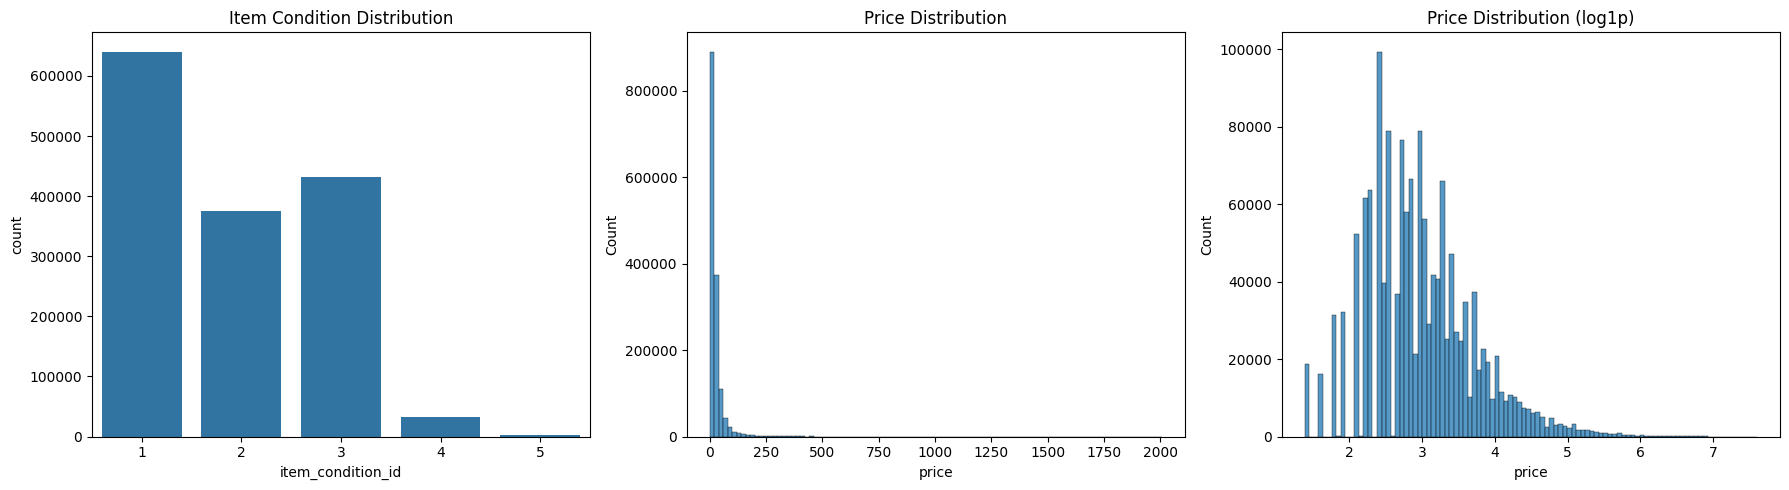

In [32]:
# 수치형 컬럼의 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# item_condition_id: 카테고리형에 가까우므로 countplot
sns.countplot(x='item_condition_id', data=train, ax=axes[0])
axes[0].set_title('Item Condition Distribution')

# price: 가격은 보통 심하게 오른쪽으로 치우쳐 있음 (right-skewed)
sns.histplot(train['price'], bins=100, ax=axes[1])
axes[1].set_title('Price Distribution')

# price 로그 변환 후 확인
sns.histplot(train['price'][train['price'] > 0].apply(np.log1p), bins=100, ax=axes[2])
axes[2].set_title('Price Distribution (log1p)')

plt.tight_layout()
plt.show()

In [28]:
train[train['price'] == 0]

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
1325,1325,Alabama Crimson Tide Quality Lanyard,1,Sports & Outdoors/Fan Shop/NCAA,NaN,0.0,1,TOP QUALITY THICK LANYARD Reversible sides wit...
2544,2544,Levi leggings,3,"Women/Jeans/Slim, Skinny",Levi's®,0.0,0,Light wash. Hardly worn. Size 24 but fits like...
2712,2712,Simple Red Lace Lingerie Top,3,Women/Underwear/G-Strings & Thongs,NaN,0.0,0,"Very simple but cute, a little form fitting as..."
3576,3576,Turquoise 15 Pc Makeup Brush Set,1,Beauty/Tools & Accessories/Makeup Brushes & Tools,NaN,0.0,1,1 left!
3761,3761,Girls size 7/8,3,Kids/Girls (4+)/Tops & T-Shirts,NaN,0.0,1,5 pair gap jean excellent used condition 3 chi...
...,...,...,...,...,...,...,...,...
1474172,1474172,Homecoming or Dama ivory dress,2,"Women/Dresses/Above Knee, Mini",NaN,0.0,0,Ivory formal dress. I wore this dress once for...
1474198,1474198,Tie up flannel top,3,Women/Tops & Blouses/Blouse,NaN,0.0,1,I got this last year and just didnt wear it mu...
1477958,1477958,Rae Dunn Measuring Pear,3,Home/Home Décor/Home Décor Accents,NaN,0.0,0,The dash lid appears it was dropped and a piec...
1478519,1478519,4 pairs women's wool boots socks,1,Women/Shoes/Boots,NaN,0.0,1,✔️SHARE YOUR SOCKS WITH FRIENDS AND FAMILY! ✔️...


In [29]:
# 가격이 0인 데이터가 있는지 꼭 확인
print(f"price == 0 인 행 수: {(train['price'] == 0).sum()}")

price == 0 인 행 수: 874


### 2. 데이터 전처리 (결측치, 이상치)

In [8]:
# 전체 결측치 현황 한눈에 보기
print("=== 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 현황 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [9]:
# 세부 컬럼별 결측치 확인
# 'category_name' 컬럼

print(f"\n▣ category_name 결측치 수: {train['category_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['category_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_category = train[train['category_name'].isna()][
    ['name', 'brand_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== category_name 결측 샘플 ===")
print(null_category.to_string())


▣ category_name 결측치 수: 6327
▣ 전체 대비 비율: 0.43%

=== category_name 결측 샘플 ===
                                             name      brand_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         item_description  price
245817                             Mini deep dome         Zoo Med                                                                                                                                                                                                         

In [10]:
# 'brand_name' 컬럼

print(f"\n▣ brand_name 결측치 수: {train['brand_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['brand_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_brand = train[train['brand_name'].isna()][
    ['name', 'category_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== brand_name 결측 샘플 ===")
print(null_brand.to_string())


▣ brand_name 결측치 수: 632682
▣ 전체 대비 비율: 42.68%

=== brand_name 결측 샘플 ===
                                             name                                   category_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                    item_description  price
519130                  Perfume & necklace Bundle                          Beauty/Fragrance/Women                                                                                                                                                                                                                                                                 

In [11]:
# 'item_description' 컬럼

print(f"\n▣ item_description 결측치 수: {train['item_description'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['item_description'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_description = train[train['item_description'].isna()][
    ['name', 'category_name', 'brand_name', 'price']
].sample(6, random_state=42)

print("\n=== item_description 결측 샘플 ===")
print(null_description.to_string())


▣ item_description 결측치 수: 6
▣ 전체 대비 비율: 0.00%

=== item_description 결측 샘플 ===
                            name                                   category_name           brand_name  price
321916        Lululemon leggings  Women/Athletic Apparel/Pants, Tights, Leggings  lululemon athletica   44.0
511535        Shoes for Michelle                       Kids/Girls 0-24 Mos/Shoes                  NaN    9.0
1425077            Lg 25um65p x2                         Electronics/Other/Other                  NaN  230.0
861230                  Lipgloss                              Beauty/Makeup/Lips                  NaN   49.0
1264242               For Bianca       Women/Women's Accessories/Scarves & Wraps                  NaN   10.0
1224924  Disney Minnie Head band      Women/Women's Accessories/Hair Accessories               Disney    9.0


In [12]:
# 'item_description' 결측치 : 'No description yet'과 동일한 값으로 처리
train['item_description'] = train['item_description'].fillna("No description yet")

In [13]:
# 'brand_name' 결측치 처리 :
# 1. 기존 브랜드명이 기재된 컬럼에는 1, 누락된 곳에는 0
# 2. 결측치처리 : 'No Brand'
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")

In [14]:
# 'category_name' 결측치 처리 : 'No Category'
train["category_name"] = train["category_name"].fillna("No category")

In [15]:
# 처리 후 전체 결측치 현황 한눈에 보기
print("=== 결측치 처리 후 데이터 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 처리 후 데이터 결측치 현황 ===
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
has_brand            0
dtype: int64


In [30]:
print(f"'No description yet'인 행 수 : {(train['item_description']=='No description yet').sum()}")

'No description yet'인 행 수 : 82489


In [21]:
train[train['item_description']=='No description yet']

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,No Brand,10.0,1,No description yet,0
13,13,Sharpener and eraser,1,Other/Office supplies/School Supplies,Scholastic,4.0,1,No description yet,1
31,31,"New Lularoe OS leggings, stars",1,"Women/Athletic Apparel/Pants, Tights, Leggings",No Brand,50.0,1,No description yet,0
90,90,Jewel holder,2,Home/Storage & Organization/Jewelry Boxes & Or...,Target,7.0,1,No description yet,1
117,117,Eyeko liquid eyeliner,1,Beauty/Makeup/Eyes,No Brand,5.0,1,No description yet,0
...,...,...,...,...,...,...,...,...,...
1482430,1482430,Nike Jordan's 5c,3,Kids/Girls 2T-5T/Shoes,Nike,14.0,0,No description yet,1
1482447,1482447,Wet n Wild Eyelashes,2,Beauty/Makeup/Eyes,Wet n Wild,3.0,1,No description yet,1
1482470,1482470,Adidas ultra boost,2,Men/Shoes/Athletic,Adidas,9.0,0,No description yet,1
1482496,1482496,Benefit they're real mascara,1,Beauty/Makeup/Eyes,Benefit,8.0,1,No description yet,1
